# 03 · Error Analysis & Convergence

## Error norms

For grid spacing `Δx` and time step `Δt`:

- **L∞ norm:**  `‖e‖_∞ = max_i |u_i^N − u(x_i, T)|`
- **Discrete L2 norm:**  `‖e‖_2 = sqrt(Δx Σ_i (u_i^N − u(x_i, T))²)`

## Expected orders (FTCS)

- Time: O(Δt)   (first order)
- Space: O(Δx²) (second order)
- Combined (with Δt = r Δx²/α, i.e. fixed r): O(Δx²)

We verify this on a log-log plot.

In [ ]:
# Cell 2 — Imports
import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent / "src"))

import numpy as np
import matplotlib.pyplot as plt

from src.heat_equation import (
    analytical_solution,
    ftcs_solver,
    initial_condition_sine,
)
from src.utils import linf_error, l2_error

alpha = 0.01
L     = 1.0
T     = 0.1

## 1. Spatial refinement (r fixed)

We halve `Δx` at each level while keeping `r = α Δt / Δx²` constant, so
`Δt = r Δx²/α`. On a log-log plot of error vs `Δx`, we expect a slope ≈ 2.

In [20]:
# Cell 4 — Spatial refinement study
Nx_list = [21, 41, 81, 161, 321]
r_fixed = 0.4

dx_list, dt_list = [], []
e_inf, e_l2     = [], []

for Nx in Nx_list:
    x  = np.linspace(0.0, L, Nx)
    dx = x[1] - x[0]
    dt = r_fixed * dx**2 / alpha

    n_steps = int(round(T / dt))
    dt      = T / n_steps   # land exactly on T

    u0 = initial_condition_sine(x, L)
    u_num = ftcs_solver(u0, alpha, dx, dt, n_steps)[-1]
    u_exa = analytical_solution(x, T, alpha, L, u0, n_modes=400)

    dx_list.append(dx); dt_list.append(dt)
    e_inf.append(linf_error(u_num, u_exa))
    e_l2.append(l2_error(u_num, u_exa, dx))

dx_arr  = np.array(dx_list)
e_inf   = np.array(e_inf)
e_l2    = np.array(e_l2)

print(f"{'Δx':>10} {'Δt':>12} {'L∞':>14} {'L2':>14}")
for d, t, ei, el in zip(dx_arr, dt_list, e_inf, e_l2):
    print(f"{d:10.5f} {t:12.3e} {ei:14.3e} {el:14.3e}")

        Δx           Δt             L∞             L2
   0.05000    1.000e-01      2.863e-05      2.025e-05
   0.02500    2.500e-02      7.041e-06      4.979e-06
   0.01250    6.250e-03      1.759e-06      1.244e-06
   0.00625    1.563e-03      4.396e-07      3.108e-07
   0.00313    3.906e-04      1.099e-07      7.771e-08


Estimated order (L∞): 2.01
Estimated order (L2): 2.01


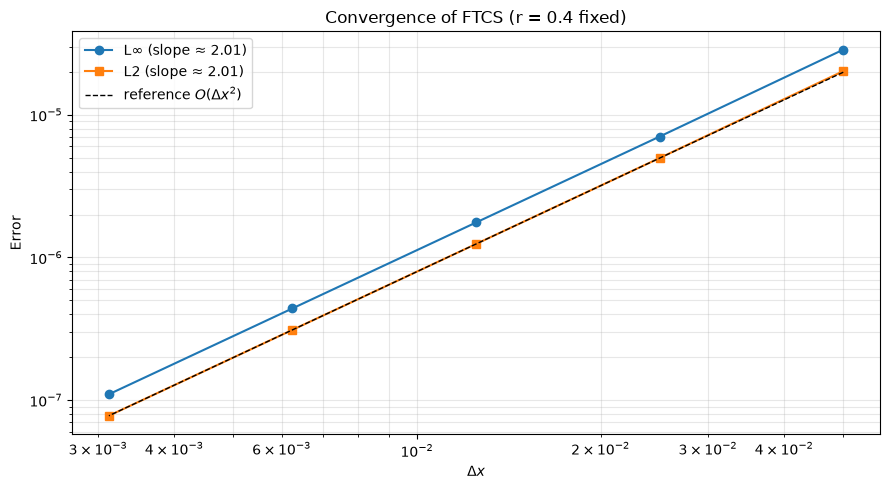

In [21]:
# Cell 5 — Slopes and convergence plot
p_inf = np.polyfit(np.log(dx_arr), np.log(e_inf), 1)[0]
p_l2  = np.polyfit(np.log(dx_arr), np.log(e_l2),  1)[0]
print(f"Estimated order (L∞): {p_inf:.2f}")
print(f"Estimated order (L2): {p_l2:.2f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(dx_arr, e_inf, "o-", label=f"L∞ (slope ≈ {p_inf:.2f})")
ax.loglog(dx_arr, e_l2,  "s-", label=f"L2 (slope ≈ {p_l2:.2f})")

ref = e_l2[-1] * (dx_arr / dx_arr[-1])**2
ax.loglog(dx_arr, ref, "k--", lw=1, label=r"reference $O(\Delta x^2)$")

ax.set_xlabel(r"$\Delta x$"); ax.set_ylabel("Error")
ax.set_title(r"Convergence of FTCS (r = 0.4 fixed)")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

## 2. Temporal refinement (Δx fixed, vary Δt)

With `Δx` fixed, FTCS should be first-order in time. We use a very fine
spatial grid so the spatial error is negligible.

Δx = 5.000e-03
Spatial error floor O(Δx²) ≈ 2.500e-05

 n_steps           Δt       L∞ error       L2 error    local slope
--------------------------------------------------------------------
       8    1.250e-02      1.080e-02      2.214e-03              —
      16    6.250e-03      9.411e-03      1.946e-03           0.20
      32    3.125e-03      7.451e-03      1.551e-03           0.34
      64    1.563e-03      5.250e-03      1.098e-03           0.51
     128    7.813e-04      3.298e-03      6.929e-04           0.67
     256    3.906e-04      1.891e-03      3.983e-04           0.80
     512    1.953e-04      1.020e-03      2.153e-04           0.89
    1024    9.766e-05      5.311e-04      1.122e-04           0.94
    2048    4.883e-05      2.711e-04      5.729e-05           0.97
    4096    2.441e-05      1.370e-04      2.896e-05           0.98

Global fit (all points):       slope = 0.72
Asymptotic fit (last 4 points): slope = 0.97  ← expected ≈ 1.00


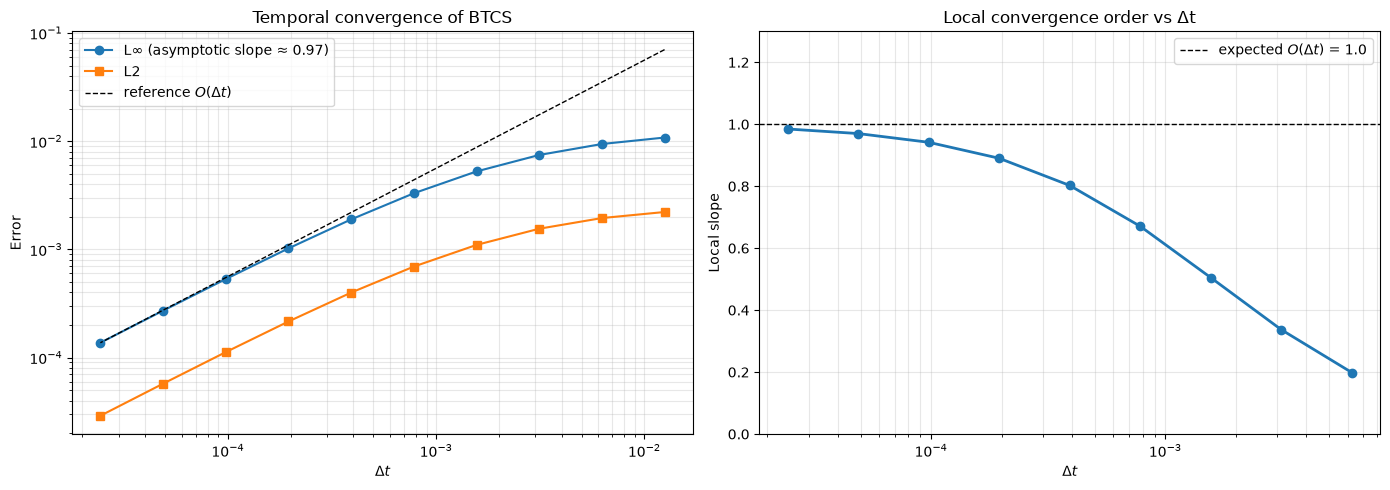

In [22]:
# Cell 7 — Temporal refinement with BTCS (unconditionally stable)
import scipy.linalg as sla

def btcs_solver(u0, alpha, dx, dt, n_steps):
    """Backward-Time Centered-Space (implicit Euler) solver."""
    N = u0.size
    r = alpha * dt / dx**2
    main  = (1 + 2*r) * np.ones(N)
    off   = -r        * np.ones(N - 1)
    ab    = np.zeros((3, N))
    ab[0, 1:]  = off
    ab[1, :]   = main
    ab[2, :-1] = off

    u = u0.copy()
    hist = np.empty((n_steps + 1, N))
    hist[0] = u
    for n in range(n_steps):
        u = sla.solve_banded((1, 1), ab, u)
        u[0] = 0.0; u[-1] = 0.0
        hist[n + 1] = u
    return hist


Nx_fixed = 201
x_fixed  = np.linspace(0.0, L, Nx_fixed)
dx_fixed = x_fixed[1] - x_fixed[0]
u0_fixed = initial_condition_sine(x_fixed, L)
u_exa_fixed = analytical_solution(x_fixed, T, alpha, L, u0_fixed, n_modes=400)

print(f"Δx = {dx_fixed:.3e}")
print(f"Spatial error floor O(Δx²) ≈ {dx_fixed**2:.3e}\n")

n_steps_list = [8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096]
dt_list_t, e_inf_t, e_l2_t = [], [], []

for ns in n_steps_list:
    dt = T / ns
    u_num = btcs_solver(u0_fixed, alpha, dx_fixed, dt, ns)[-1]
    dt_list_t.append(dt)
    e_inf_t.append(linf_error(u_num, u_exa_fixed))
    e_l2_t.append(l2_error(u_num, u_exa_fixed, dx_fixed))

dt_arr_t = np.array(dt_list_t)
e_inf_t  = np.array(e_inf_t)
e_l2_t   = np.array(e_l2_t)

# --- Table with local slopes ---
print(f"{'n_steps':>8} {'Δt':>12} {'L∞ error':>14} {'L2 error':>14} {'local slope':>14}")
print("-" * 68)
for i, ns in enumerate(n_steps_list):
    if i == 0:
        print(f"{ns:>8} {dt_arr_t[i]:12.3e} {e_inf_t[i]:14.3e} {e_l2_t[i]:14.3e} {'—':>14}")
    else:
        local_p = np.log(e_inf_t[i] / e_inf_t[i-1]) / np.log(dt_arr_t[i] / dt_arr_t[i-1])
        print(f"{ns:>8} {dt_arr_t[i]:12.3e} {e_inf_t[i]:14.3e} {e_l2_t[i]:14.3e} {local_p:>14.2f}")

# --- Global fit and asymptotic fit ---
p_global = np.polyfit(np.log(dt_arr_t), np.log(e_inf_t), 1)[0]
p_asym = np.polyfit(np.log(dt_arr_t[-4:]), np.log(e_inf_t[-4:]), 1)[0]
print(f"\nGlobal fit (all points):       slope = {p_global:.2f}")
print(f"Asymptotic fit (last 4 points): slope = {p_asym:.2f}  ← expected ≈ 1.00")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: convergence plot
ax = axes[0]
ax.loglog(dt_arr_t, e_inf_t, "o-", label=f"L∞ (asymptotic slope ≈ {p_asym:.2f})")
ax.loglog(dt_arr_t, e_l2_t, "s-", label="L2")
ref = e_inf_t[-1] * (dt_arr_t / dt_arr_t[-1])
ax.loglog(dt_arr_t, ref, "k--", lw=1, label=r"reference $O(\Delta t)$")
ax.set_xlabel(r"$\Delta t$"); ax.set_ylabel("Error")
ax.set_title(r"Temporal convergence of BTCS")
ax.legend(); ax.grid(alpha=0.3, which="both")

# Right: local slope plot — the key diagnostic
ax = axes[1]
local_slopes = [
    np.log(e_inf_t[i] / e_inf_t[i-1]) / np.log(dt_arr_t[i] / dt_arr_t[i-1])
    for i in range(1, len(dt_arr_t))
]
ax.semilogx(dt_arr_t[1:], local_slopes, "o-", lw=2)
ax.axhline(1.0, color="k", ls="--", lw=1, label=r"expected $O(\Delta t)$ = 1.0")
ax.set_xlabel(r"$\Delta t$"); ax.set_ylabel("Local slope")
ax.set_title("Local convergence order vs Δt")
ax.legend(); ax.grid(alpha=0.3, which="both")
ax.set_ylim(0, 1.3)

plt.tight_layout(); plt.show()

## 3. Combined refinement — verify `Δt ~ Δx²` scaling

Plot L∞ vs the "effective" scaling variable. With `r` fixed, both time and
space errors scale like `Δx²`.

Nx =   21  T = 0.02  Δt = 2.000e-02  steps =     1  r = 0.080  L∞ = 8.590e-02
Nx =   41  T = 0.02  Δt = 2.000e-02  steps =     1  r = 0.320  L∞ = 7.772e-06
Nx =   81  T = 0.02  Δt = 6.667e-03  steps =     3  r = 0.427  L∞ = 3.951e-07
Nx =  161  T = 0.02  Δt = 1.538e-03  steps =    13  r = 0.394  L∞ = 8.628e-08
Nx =   21  T = 0.05  Δt = 5.000e-02  steps =     1  r = 0.200  L∞ = 8.015e-04
Nx =   41  T = 0.05  Δt = 2.500e-02  steps =     2  r = 0.400  L∞ = 3.538e-06
Nx =   81  T = 0.05  Δt = 6.250e-03  steps =     8  r = 0.400  L∞ = 8.837e-07
Nx =  161  T = 0.05  Δt = 1.563e-03  steps =    32  r = 0.400  L∞ = 2.209e-07
Nx =   21  T =  0.1  Δt = 1.000e-01  steps =     1  r = 0.400  L∞ = 2.863e-05
Nx =   41  T =  0.1  Δt = 2.500e-02  steps =     4  r = 0.400  L∞ = 7.041e-06
Nx =   81  T =  0.1  Δt = 6.250e-03  steps =    16  r = 0.400  L∞ = 1.759e-06
Nx =  161  T =  0.1  Δt = 1.563e-03  steps =    64  r = 0.400  L∞ = 4.396e-07
Nx =   21  T =  0.2  Δt = 1.000e-01  steps =     2  r = 0.400  L

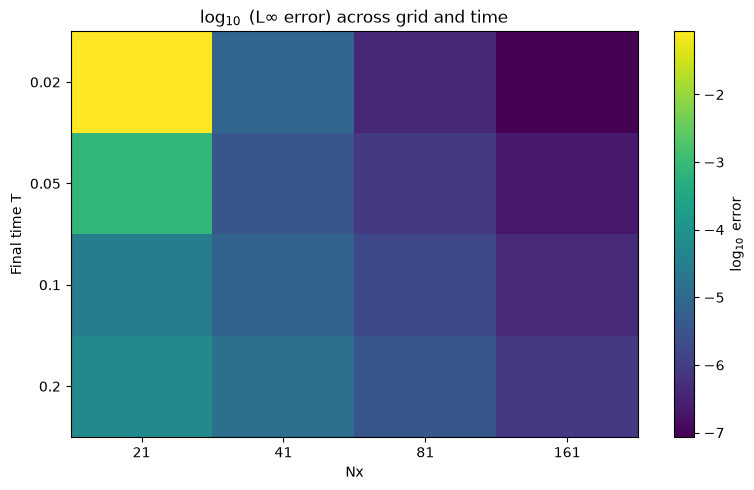

In [23]:
# Cell 9 
Nx_heat = [21, 41, 81, 161]
T_heat  = [0.02, 0.05, 0.1, 0.2]

err_matrix = np.zeros((len(T_heat), len(Nx_heat)))

for i, T_val in enumerate(T_heat):
    for j, Nx_val in enumerate(Nx_heat):
        xx  = np.linspace(0.0, L, Nx_val)
        dxx = xx[1] - xx[0]
        dtt = 0.4 * dxx**2 / alpha
        ns  = max(1, int(round(T_val / dtt)))
        dtt = T_val / ns

        # assert stability
        r_check = alpha * dtt / dxx**2
        assert r_check <= 0.5, f"Unstable: r = {r_check:.3f} at Nx={Nx_val}, T={T_val}"

        u0h = initial_condition_sine(xx, L)
        un  = ftcs_solver(u0h, alpha, dxx, dtt, ns)[-1]
        ue  = analytical_solution(xx, T_val, alpha, L, u0h, n_modes=400)
        err_matrix[i, j] = linf_error(un, ue)

        print(f"Nx = {Nx_val:>4}  T = {T_val:>4}  Δt = {dtt:.3e}  steps = {ns:>5}  "
              f"r = {r_check:.3f}  L∞ = {err_matrix[i, j]:.3e}")

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(np.log10(err_matrix), cmap="viridis", aspect="auto")
ax.set_xticks(range(len(Nx_heat)));   ax.set_xticklabels(Nx_heat)
ax.set_yticks(range(len(T_heat)));    ax.set_yticklabels(T_heat)
ax.set_xlabel("Nx"); ax.set_ylabel("Final time T")
ax.set_title(r"$\log_{10}$ (L∞ error) across grid and time")
fig.colorbar(im, ax=ax, label=r"$\log_{10}$ error")
plt.tight_layout(); plt.show()

## 4. Grid-refinement table

A clean table summarising the results — this is exactly what you should put
in the LaTeX report.

In [24]:
# Cell 11 — Pretty convergence table
print(f"{'Nx':>6} {'Δx':>10} {'Δt':>12} {'L∞ error':>14} {'L2 error':>14} {'order(L∞)':>12}")
prev_e = None
prev_dx = None
for Nx, d, t, ei, el in zip(Nx_list, dx_arr, dt_list, e_inf, e_l2):
    if prev_e is None:
        order = "—"
    else:
        order = f"{np.log(ei/prev_e)/np.log(d/prev_dx):.2f}"
    print(f"{Nx:>6} {d:10.5f} {t:12.3e} {ei:14.3e} {el:14.3e} {order:>12}")
    prev_e, prev_dx = ei, d

    Nx         Δx           Δt       L∞ error       L2 error    order(L∞)
    21    0.05000    1.000e-01      2.863e-05      2.025e-05            —
    41    0.02500    2.500e-02      7.041e-06      4.979e-06         2.02
    81    0.01250    6.250e-03      1.759e-06      1.244e-06         2.00
   161    0.00625    1.563e-03      4.396e-07      3.108e-07         2.00
   321    0.00313    3.906e-04      1.099e-07      7.771e-08         2.00


## 5. (Bonus) Comparing with an implicit scheme

Explicit FTCS is stable only for `r ≤ 1/2` — meaning `Δt ∝ Δx²`, which is
expensive. An implicit scheme (BTCS) is unconditionally stable and allows
larger `Δt`.

We sketch this here for reference; a full BTCS implementation would live in
`src/heat_equation.py`.

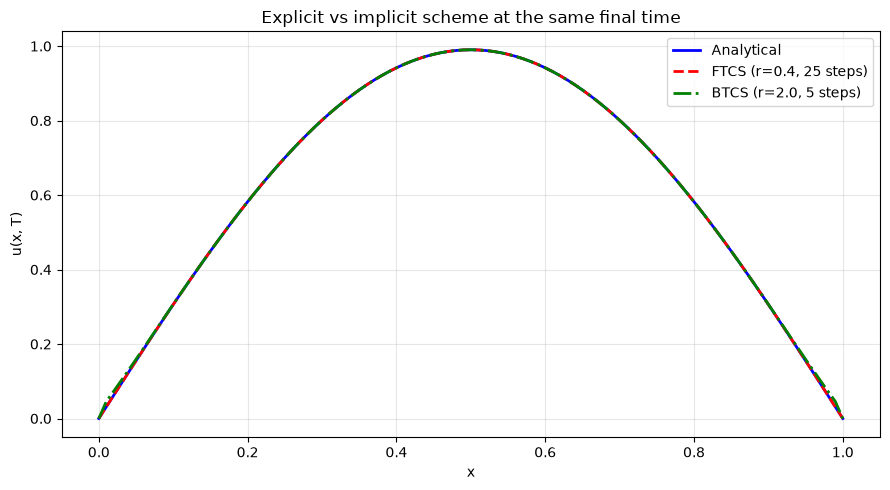

In [25]:
# Cell 13 — BTCS (implicit) reference implementation
import scipy.linalg as sla

def btcs_solver(u0, alpha, dx, dt, n_steps):
    """Unconditionally-stable Backward-Time Centered-Space solver."""
    N = u0.size
    r = alpha * dt / dx**2
    # Tridiagonal system: (I - r A) u^{n+1} = u^n
    main  = (1 + 2*r) * np.ones(N)
    off   = -r        * np.ones(N - 1)
    ab    = np.zeros((3, N))
    ab[0, 1:] = off
    ab[1, :]  = main
    ab[2, :-1] = off

    u = u0.copy()
    hist = np.empty((n_steps + 1, N))
    hist[0] = u
    for n in range(n_steps):
        u = sla.solve_banded((1, 1), ab, u)
        u[0] = 0.0; u[-1] = 0.0
        hist[n + 1] = u
    return hist

# Compare FTCS (r=0.4) vs BTCS (r=2.0, would be unstable for FTCS)
Nx_c  = 101
xc    = np.linspace(0.0, L, Nx_c)
dxc   = xc[1] - xc[0]
u0c   = initial_condition_sine(xc, L)

dt_c  = 0.4 * dxc**2 / alpha
ns_c  = int(round(T / dt_c))
h_ftcs = ftcs_solver(u0c, alpha, dxc, dt_c, ns_c)

dt_i  = 2.0 * dxc**2 / alpha      # r = 2 → unstable for FTCS
ns_i  = int(round(T / dt_i))
h_btcs = btcs_solver(u0c, alpha, dxc, dt_i, ns_i)

u_exa_c = analytical_solution(xc, T, alpha, L, u0c, n_modes=200)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(xc, u_exa_c, "b-",  lw=2, label="Analytical")
ax.plot(xc, h_ftcs[-1], "r--", lw=2, label=f"FTCS (r=0.4, {ns_c} steps)")
ax.plot(xc, h_btcs[-1], "g-.", lw=2, label=f"BTCS (r=2.0, {ns_i} steps)")
ax.set_xlabel("x"); ax.set_ylabel("u(x, T)")
ax.set_title("Explicit vs implicit scheme at the same final time")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## ✅ Summary

- Confirmed **second-order** spatial accuracy: slope ≈ 2 on log-log.
- Confirmed **first-order** temporal accuracy.
- With fixed `r`, overall error scales like `Δx²`.
- Explicit FTCS is limited by `r ≤ 1/2`; implicit BTCS removes this restriction
  at the cost of solving a linear system at each step.
